STEP 0 — Loading Xenium spatial coordinates
Xenium total cells: 167,780
STEP 1 — Building intersection & downsampling
  DCIS_1: intersection=12923
  DCIS_2: intersection=11683
  Prolif_Invasive_Tumor: intersection=3775
  Invasive_Tumor: intersection=34374

Downsampled counts (original clusters):
  DCIS_1                        : 10,000
  DCIS_2                        : 10,000
  Invasive_Tumor                : 6,225
  Prolif_Invasive_Tumor         : 3,775

3-class distribution after merging:
  Tumor (Invasive+Prolif)       : 10,000
  DCIS_1                        : 10,000
  DCIS_2                        : 10,000
STEP 2 — Stratified random split (70 / 15 / 15)
Split sizes:
split
train    21000
val       4500
test      4500

Class distribution per split:
label     0     1     2
split                  
test   1500  1500  1500
train  7000  7000  7000
val    1500  1500  1500
STEP 3 — Strategy 1: removing overlapping test cells
Test cells (original):       4,500
Test cells (after cleaning): 2

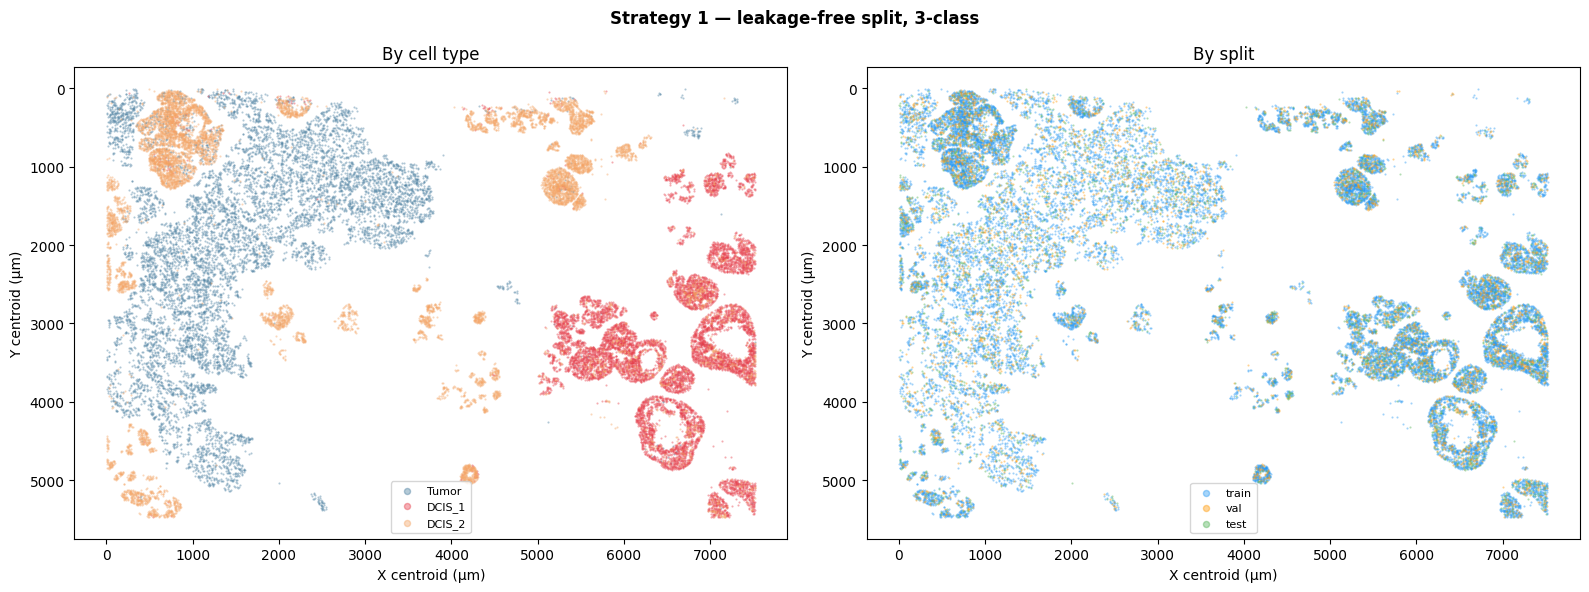

Saved → /kaggle/working/strategy1/spatial_split_s1.png
Preprocessing complete.
  strategy1/    master_labels_s1.csv, norm_stats.csv,
                 gnn_nodes.csv, gnn_edges.csv, spatial_split_s1.png
  strategy2/    master_labels_s2.csv (+ masked columns), norm_stats.csv


In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.neighbors import BallTree
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# CONFIG
IMAGE_DIRS_100 = {
    'DCIS_1':                '/kaggle/input/datasets/eva233333/tumor-cell-dcis-2/DCIS_1/DCIS_1/',
    'DCIS_2':                '/kaggle/input/datasets/eva233333/tumor-cell-dcis-2/DCIS_2/DCIS_2/',
    'Prolif_Invasive_Tumor': '/kaggle/input/datasets/eva233333/tumor-cell-dcis-2/Prolif_Invasive_Tumor/Prolif_Invasive_Tumor/',
    'Invasive_Tumor':        '/kaggle/input/datasets/eva233333/tumor-cell-dcis-2/Invasive_Tumor/Invasive_Tumor/',
}
IMAGE_DIRS_50 = {
    'DCIS_1':                '/kaggle/input/datasets/eva233333/50px-tumor-cell/DCIS_1/DCIS_1/',
    'DCIS_2':                '/kaggle/input/datasets/eva233333/50px-tumor-cell/DCIS_2/DCIS_2/',
    'Prolif_Invasive_Tumor': '/kaggle/input/datasets/eva233333/50px-tumor-cell/Prolif_Invasive_Tumor (1)/Prolif_Invasive_Tumor/',
    'Invasive_Tumor':        '/kaggle/input/datasets/eva233333/50px-tumor-cell/Invasive_Tumor (1)/Invasive_Tumor/',
}
EXCEL_PATH = '/kaggle/input/datasets/eva233333/data3888-grp/41467_2023_43458_MOESM4_ESM.xlsx'

LABEL_MAP = {
    'DCIS_1':                1,
    'DCIS_2':                2,
    'Prolif_Invasive_Tumor': 0,
    'Invasive_Tumor':        0,
}

TARGET_PER_CLASS = {
    'DCIS_1':                10000,
    'DCIS_2':                10000,
    'Prolif_Invasive_Tumor': 3775,
    'Invasive_Tumor':        6225,
}

OUT_DIR          = '/kaggle/working/'
SEED             = 42
NORM_SAMPLE      = 1000
PATCH_RADIUS_UM  = 10.0
MASK_KEEP_RATIO  = 0.30
MASK_FILL        = np.array([123, 116, 103], dtype=np.uint8)
MASKED_DIR = OUT_DIR + 'masked_patches/'

random.seed(SEED)
np.random.seed(SEED)


def get_cell_id(filename):
    return int(filename.split('_')[1])


# STEP 0 — Load Xenium spatial coordinates
print("STEP 0 — Loading Xenium spatial coordinates")

xl     = pd.read_excel(EXCEL_PATH, sheet_name='Fig. 3e-j Xenium')
xenium = xl.copy()
xenium['Cluster'] = xenium['Cluster'].str.replace(' ', '_')
xenium['cell_id'] = range(1, len(xenium) + 1)
print(f"Xenium total cells: {len(xenium):,}")


# STEP 1 — Build intersection & downsample
print("STEP 1 — Building intersection & downsampling")

ids_both = {}
for cl in IMAGE_DIRS_100.keys():
    ids_100 = set(get_cell_id(f) for f in os.listdir(IMAGE_DIRS_100[cl]) if f.endswith('.png'))
    ids_50  = set(get_cell_id(f) for f in os.listdir(IMAGE_DIRS_50[cl])  if f.endswith('.png'))
    ids_both[cl] = ids_100 & ids_50
    print(f"  {cl}: intersection={len(ids_both[cl])}")

records = []
for cl, cell_ids in ids_both.items():
    cell_ids_list = list(cell_ids)
    target        = TARGET_PER_CLASS[cl]
    sampled_ids   = random.sample(cell_ids_list, target) if len(cell_ids_list) > target else cell_ids_list
    for cid in sampled_ids:
        records.append({
            'cell_id':   cid,
            'cluster':   cl,
            'label':     LABEL_MAP[cl],
            'path_100':  os.path.join(IMAGE_DIRS_100[cl], f'cell_{cid}_100.png'),
            'path_50':   os.path.join(IMAGE_DIRS_50[cl],  f'cell_{cid}_50.png'),
        })

real_df = pd.DataFrame(records)

print("\nDownsampled counts (original clusters):")
for cl, n in real_df['cluster'].value_counts().items():
    print(f"  {cl:<30}: {n:,}")

label_names = {0: 'Tumor (Invasive+Prolif)', 1: 'DCIS_1', 2: 'DCIS_2'}
print("\n3-class distribution after merging:")
for lbl, n in real_df.groupby('label').size().items():
    print(f"  {label_names[lbl]:<30}: {n:,}")


# STEP 2 — Stratified split 70/15/15
print("STEP 2 — Stratified random split (70 / 15 / 15)")

train_val_df, test_df = train_test_split(
    real_df, test_size=0.15,
    stratify=real_df['label'], random_state=SEED)
train_df, val_df      = train_test_split(
    train_val_df, test_size=0.15 / 0.85,
    stratify=train_val_df['label'], random_state=SEED)

real_df['split'] = 'train'
real_df.loc[val_df.index,  'split'] = 'val'
real_df.loc[test_df.index, 'split'] = 'test'

print("Split sizes:")
print(real_df['split'].value_counts().to_string())
print("\nClass distribution per split:")
print(real_df.groupby(['split', 'label']).size().unstack(fill_value=0).to_string())


# STEP 3 — Strategy 1: Remove test cells that overlap
print("STEP 3 — Strategy 1: removing overlapping test cells")

real_with_coords = real_df.merge(
    xenium[['cell_id', 'x_centroid', 'y_centroid']],
    on='cell_id', how='left'
)
missing = real_with_coords['x_centroid'].isna().sum()
if missing > 0:
    print(f"WARNING: {missing} cells missing coordinates, dropping.")
    real_with_coords = real_with_coords.dropna(
        subset=['x_centroid', 'y_centroid']).copy()
    real_df = real_df[real_df['cell_id'].isin(
        real_with_coords['cell_id'])].copy()

tv_mask   = real_with_coords['split'].isin(['train', 'val'])
test_mask = real_with_coords['split'] == 'test'

tv_coords     = real_with_coords.loc[tv_mask,   ['x_centroid', 'y_centroid']].values
test_coords   = real_with_coords.loc[test_mask, ['x_centroid', 'y_centroid']].values
test_cell_ids = real_with_coords.loc[test_mask, 'cell_id'].values

tree   = BallTree(tv_coords)
counts = tree.query_radius(test_coords, r=PATCH_RADIUS_UM, count_only=True)

clean_mask     = counts == 0
clean_test_ids = set(test_cell_ids[clean_mask])

n_orig  = int(test_mask.sum())
n_clean = len(clean_test_ids)
print(f"Test cells (original):       {n_orig:,}")
print(f"Test cells (after cleaning): {n_clean:,}")
print(f"Removed (context overlap):   {n_orig - n_clean:,} "
      f"({(n_orig - n_clean) / n_orig * 100:.1f}%)")

real_df['split_s1'] = real_df['split'].copy()
real_df.loc[
    (real_df['split'] == 'test') & (~real_df['cell_id'].isin(clean_test_ids)),
    'split_s1'
] = 'excluded'

print("\n[Strategy 1] Clean test class distribution:")
print(real_df[real_df['split_s1'] == 'test']['label'].value_counts().to_string())


# STEP 4 — Build and save master CSVs
print("STEP 4 — Building and saving master CSVs")

os.makedirs(OUT_DIR + 'strategy1', exist_ok=True)
os.makedirs(OUT_DIR + 'strategy2', exist_ok=True)

# Strategy 1 — leakage-free, no masking
s1_df = real_df[real_df['split_s1'] != 'excluded'].copy()
s1_df = s1_df.drop(columns=['split']).rename(columns={'split_s1': 'split'})
s1_df.to_csv(OUT_DIR + 'strategy1/master_labels_s1.csv', index=False)
print(f"[Strategy 1] Total: {len(s1_df):,}  |  "
      f"Train: {(s1_df['split']=='train').sum():,}  |  "
      f"Val: {(s1_df['split']=='val').sum():,}  |  "
      f"Test: {(s1_df['split']=='test').sum():,}")

# Strategy 2 — original split, masking applied later
s2_df = real_df.drop(columns=['split_s1']).copy()
s2_df.to_csv(OUT_DIR + 'strategy2/master_labels_s2.csv', index=False)
print(f"[Strategy 2] Total: {len(s2_df):,}")


# STEP 5 — Strategy 2: Pre-generate masked patches
print("STEP 5 — Strategy 2: generating masked patches")
os.makedirs(MASKED_DIR, exist_ok=True)

def masked_path(original_path):
    filename  = os.path.basename(original_path)
    base, ext = os.path.splitext(filename)
    return os.path.join(MASKED_DIR, base + '_masked' + ext)


def make_masked_patch(img_path, keep_ratio=MASK_KEEP_RATIO):
    img    = np.array(Image.open(img_path).convert('RGB'))
    h, w   = img.shape[:2]
    cx, cy = w // 2, h // 2
    radius = int(min(h, w) * keep_ratio)
    Y, X   = np.ogrid[:h, :w]
    inside = (X - cx) ** 2 + (Y - cy) ** 2 <= radius ** 2
    result = np.full_like(img, fill_value=MASK_FILL)
    result[inside] = img[inside]
    return Image.fromarray(result)


unique_paths = set()
for col in ['path_100', 'path_50']:
    unique_paths.update(s2_df[col].unique())
print(f"Unique image paths to mask: {len(unique_paths):,}")

n_done = 0
for fpath in unique_paths:
    out_path = masked_path(fpath)
    if not os.path.exists(out_path):
        try:
            make_masked_patch(fpath).save(out_path)
        except Exception as e:
            print(f"  WARNING: could not mask {fpath}: {e}")
    n_done += 1
    if n_done % 5000 == 0:
        print(f"  Processed {n_done:,} / {len(unique_paths):,}")

print(f"Masking complete: {n_done:,} files processed.")

s2_df['path_100_masked'] = s2_df['path_100'].apply(masked_path)
s2_df['path_50_masked']  = s2_df['path_50'].apply(masked_path)
s2_df.to_csv(OUT_DIR + 'strategy2/master_labels_s2.csv', index=False)


# STEP 6 — GNN nodes & edges (Strategy 1 clean set)
print("STEP 6 — GNN nodes & edges (Strategy 1)")

valid_ids = set(s1_df['cell_id'])
nodes = xenium[xenium['cell_id'].isin(valid_ids)][
    ['cell_id', 'x_centroid', 'y_centroid', 'Cluster']
].copy()
nodes = nodes.merge(s1_df[['cell_id', 'label', 'split']], on='cell_id', how='inner').reset_index(drop=True)

print(f"GNN Nodes: {len(nodes):,}")
print(nodes['split'].value_counts().to_string())

K, edge_list = 6, []
for split_name in ['train', 'val', 'test']:
    sn = nodes[nodes['split'] == split_name].reset_index(drop=True)
    if len(sn) <= K:
        continue
    tree_s             = BallTree(sn[['x_centroid', 'y_centroid']].values)
    distances, indices = tree_s.query(sn[['x_centroid', 'y_centroid']].values, k=K + 1)
    for i in range(len(sn)):
        for j_pos in range(1, K + 1):
            edge_list.append({
                'src_cell_id': sn.iloc[i]['cell_id'],
                'tgt_cell_id': sn.iloc[indices[i, j_pos]]['cell_id'],
                'distance_um': distances[i, j_pos],
                'split':       split_name,
            })

edges = pd.DataFrame(edge_list)
print(f"GNN Edges: {len(edges):,}  |  Mean distance: {edges['distance_um'].mean():.2f} µm")

nodes.to_csv(OUT_DIR + 'strategy1/gnn_nodes.csv', index=False)
edges.to_csv(OUT_DIR + 'strategy1/gnn_edges.csv', index=False)


# STEP 7 — Normalisation stats
print("STEP 7 — Computing normalisation stats")

train_paths  = s1_df[s1_df['split'] == 'train']['path_100'].tolist()
sample_paths = random.sample(train_paths, min(NORM_SAMPLE, len(train_paths)))

pixel_sum, pixel_sq, pixel_count = np.zeros(3), np.zeros(3), 0
for fpath in sample_paths:
    img          = np.array(Image.open(fpath).convert('RGB')) / 255.0
    pixel_sum   += img.sum(axis=(0, 1))
    pixel_sq    += (img ** 2).sum(axis=(0, 1))
    pixel_count += img.shape[0] * img.shape[1]

MEAN = pixel_sum / pixel_count
STD  = np.sqrt(pixel_sq / pixel_count - MEAN ** 2)
print(f"Mean (R,G,B): {MEAN.round(4).tolist()}")
print(f"Std  (R,G,B): {STD.round(4).tolist()}")

norm_df = pd.DataFrame({'mean': MEAN, 'std': STD})
norm_df.to_csv(OUT_DIR + 'strategy1/norm_stats.csv', index=False)
norm_df.to_csv(OUT_DIR + 'strategy2/norm_stats.csv', index=False)


# STEP 8 — Visualisation
print("STEP 8 — Spatial distribution visualisation")

vis_df = s1_df.merge(
    xenium[['cell_id', 'x_centroid', 'y_centroid']], on='cell_id', how='left')

COLORS_CLASS = {0: '#457B9D', 1: '#E63946', 2: '#F4A261'}
CLASS_NAMES  = {0: 'Tumor', 1: 'DCIS_1', 2: 'DCIS_2'}
COLORS_SPLIT = {'train': '#2196F3', 'val': '#FF9800', 'test': '#4CAF50'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Strategy 1 — leakage-free split, 3-class', fontweight='bold')

for lbl, c in COLORS_CLASS.items():
    sub = vis_df[vis_df['label'] == lbl]
    axes[0].scatter(sub['x_centroid'], sub['y_centroid'],
                    c=c, s=0.3, alpha=0.4, label=CLASS_NAMES[lbl], rasterized=True)
axes[0].set_title('By cell type')
axes[0].set_xlabel('X centroid (µm)')
axes[0].set_ylabel('Y centroid (µm)')
axes[0].invert_yaxis()
axes[0].legend(markerscale=8, fontsize=8)

for sp, c in COLORS_SPLIT.items():
    sub = vis_df[vis_df['split'] == sp]
    axes[1].scatter(sub['x_centroid'], sub['y_centroid'],
                    c=c, s=0.3, alpha=0.4, label=sp, rasterized=True)
axes[1].set_title('By split')
axes[1].set_xlabel('X centroid (µm)')
axes[1].set_ylabel('Y centroid (µm)')
axes[1].invert_yaxis()
axes[1].legend(markerscale=8, fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR + 'strategy1/spatial_split_s1.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUT_DIR}strategy1/spatial_split_s1.png")

print("Preprocessing complete.")
print(f"  strategy1/    master_labels_s1.csv, norm_stats.csv,")
print(f"                 gnn_nodes.csv, gnn_edges.csv, spatial_split_s1.png")
print(f"  strategy2/    master_labels_s2.csv (+ masked columns), norm_stats.csv")
